In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

import gps_sim
import prn

# Carrier Tracking

In [40]:
f_s = 16e6
f_if = 4e6

samples = gps_sim.generate_gps(
    f_s=f_s,
    n=int(f_s * 4),
    sv=1,
    doppler=f_if,
    doppler2=100,
    code_phase=0,
    signal_power=-130,
)

In [41]:
# Do filtering

filt_bw = 4e6
filt_taps = 35

h = signal.firwin(filt_taps, filt_bw/2, fs=f_s).astype(np.complex64)
h = h * np.exp(2j*np.pi*f_if*np.arange(len(h))/f_s)

samples = np.convolve(samples, h, mode='same')
samples = samples / np.max(np.abs(samples))

In [42]:
class PLL:
    def __init__(self, bw: float, zeta: float, gain: float, ts: float):
        """Phase locked loop

        Args:
            bw (float): Noise bandwidth
            zeta (float): Damping ratio
            gain (float): Loop gain
            ts (float): Sampling time
        """

        self.set_params(bw, zeta, gain, ts)

        self.last_err = 0
        self.last_nco = 0

    def set_params(self, bw: float, zeta: float, gain: float, ts: float):
        w_n = 8 * zeta * bw / (4 * zeta**2 +1)
        tau1 = gain / (w_n**2)
        tau2 = 2 * zeta / w_n

        self.c1 = tau2 / tau1
        self.c2 = ts / tau1

    def update(self, err):
        nco = self.last_nco + self.c1 * (err - self.last_err) + err * self.c2

        self.last_err = err
        self.last_nco = nco

        return nco

    def reset(self):
        self.last_err = 0
        self.last_nco = 0

In [43]:
f_carrier = f_if + 100 # Starting carrier frequency estimate

In [69]:
carrier_pll = PLL(25, 0.707, 0.25, 1e-3)

carrier_phase = 0
carrier_freq = f_carrier

ms_count = int(1e3 * len(samples) / f_s)

sample_position = 0
sample_step = int(f_s / 1e3)

code_ref = prn.sample(1, f_s, sample_step)

res_carr_freq = []
res_carr_err = []
res_iq = []

for t_ms in range(ms_count):
    # Get chunk of data
    raw_signal = samples[sample_position:sample_position + sample_step]
    sample_position = sample_position + sample_step

    # Exit if not enough samples
    if len(raw_signal) < sample_step:
        break

    # TODO: add multiple code replicas for code tracking
    code = code_ref

    # Advance phase
    t = np.arange(sample_step + 1) / f_s
    phase = carrier_freq * 2 * np.pi * t + carrier_phase
    carrier_phase = phase[-1] % (2 * np.pi)

    # Shift to DC, remove PRN, and sum
    baseband = raw_signal * np.exp(1j * phase[:-1])
    despread = code * baseband
    prompt = np.sum(despread)

    # Update PLL
    err = np.arctan(prompt.imag / prompt.real) / (2 * np.pi)
    carrier_freq = f_carrier - carrier_pll.update(err)

    # Save stuff for graphing and debugging
    res_carr_freq.append(carrier_freq)
    res_carr_err.append(err)
    res_iq.append(prompt)

res_iq = np.array(res_iq, dtype=np.complex64)

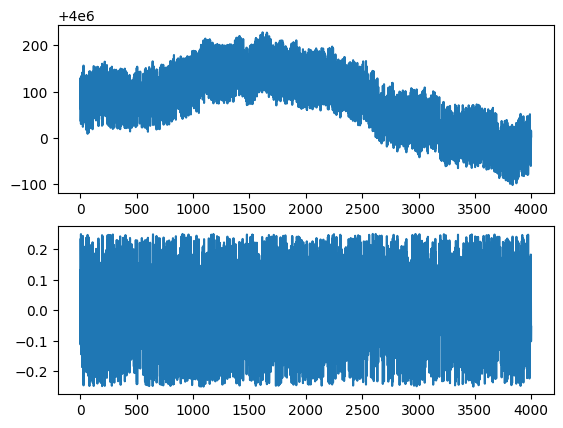

In [70]:
plt.subplot(2, 1, 1)
plt.plot(res_carr_freq)
plt.subplot(2, 1, 2)
plt.plot(res_carr_err)

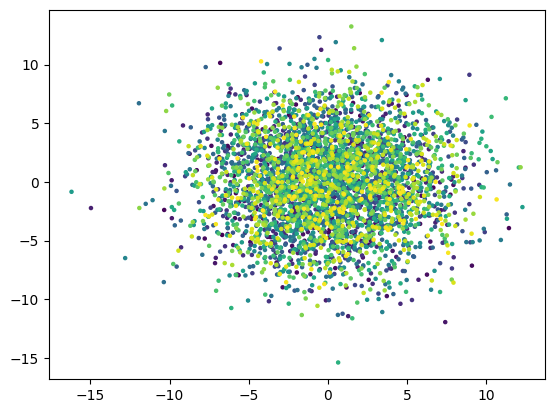

In [71]:
plt.scatter(res_iq.real, res_iq.imag, s=5, c=np.arange(len(res_iq)))

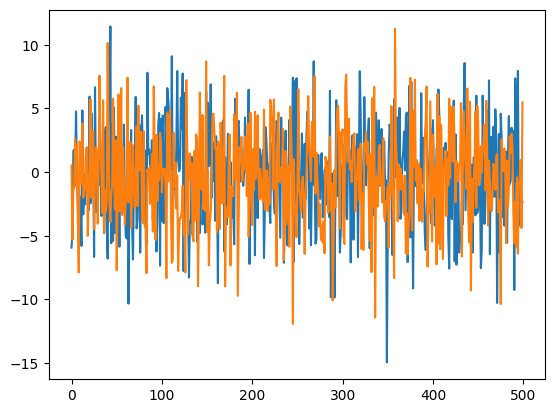

In [73]:
plt.plot(res_iq.real[0:500])
plt.plot(res_iq.imag[0:500])